Yohance Garrett López - Centro Universitario de Guadalajara - 224164481

Licenciatura en IA y CD - Data Mining - 31 de Agosto 2026

In [34]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

1. Carga de datos

In [17]:
from google.colab import files
df = pd.read_csv('movies_metadata.csv')
df.head()

/tmp/ipykernel_1382/4043506549.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


2. Limpieza de datos

In [25]:
data = [
    'budget',
    'revenue',
    'genres',
    'release_date',
    'popularity'
]

df = df[data].copy() #Datos relevantes

In [20]:
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

In [26]:
df['is_hit'] = (df['revenue'] >= 2 * df['budget']).astype(int) #Variable objetivo

def parse_json_column(text):
    try:
        return [item['name'] for item in json.loads(text)]
    except (json.JSONDecodeError, TypeError):
        return []

df['genres_list'] = df['genres'].apply(parse_json_column)#Lista de generos

3. Transformación de datos

In [27]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_month'] = df['release_date'].dt.month.fillna(0)
df['release_dayofweek'] = df['release_date'].dt.dayofweek.fillna(0) #Feature Engineering

In [28]:
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['genres_list']),
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=df.index
) #Multihot encoding

base_features = ['budget', 'popularity', 'release_month', 'release_dayofweek']
X = pd.concat([df[base_features], genre_encoded], axis=1)
y = df['is_hit']

4. Data Mining

In [31]:
print("--- 4A: Distribución de la clase objetivo ---")
print(y.value_counts(normalize=True).rename({1: 'Hit', 0: 'Flop'}))

print("\n--- 4A: Correlacion de las features con hits ---")
correlations = X.apply(lambda col: col.corr(y)).sort_values(ascending=False)
print(correlations.head(10)) #Descubrimiento de patrones

--- 4A: Distribución de la clase objetivo ---
is_hit
Hit     0.511987
Flop    0.488013
Name: proportion, dtype: float64

--- 4A: Correlacion de las features con hits ---
popularity           0.144872
budget               0.058614
release_month        0.011447
release_dayofweek   -0.059502
dtype: float64


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train) #Patron de extracción de Machine Learning con Random Forest

RandomForestClassifier(random_state=42)

5. Evaluacion de patrones y presentación de conocimiento

In [32]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n--- KDD PASO 5: Evaluacion de métricas del modelo ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print(classification_report(y_test, y_pred))


--- KDD PASO 5: Evaluacion de métricas del modelo ---
ROC-AUC Score: 0.6730

              precision    recall  f1-score   support

           0       0.63      0.60      0.62       526
           1       0.64      0.66      0.65       551

    accuracy                           0.63      1077
   macro avg       0.63      0.63      0.63      1077
weighted avg       0.63      0.63      0.63      1077



/tmp/ipykernel_1382/1700674995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.head(10).values, y=importance.head(10).index, palette='viridis')


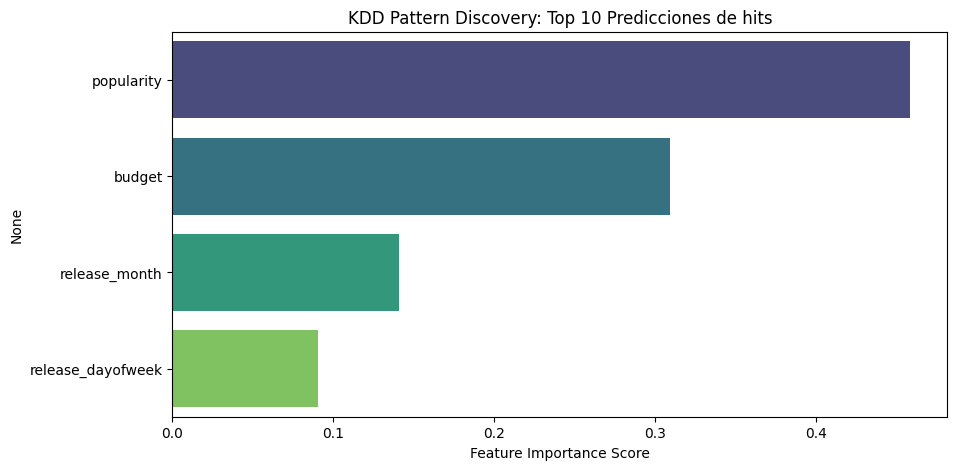

In [35]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=importance.head(10).values, y=importance.head(10).index, palette='viridis')
plt.title("KDD Pattern Discovery: Top 10 Predicciones de hits")
plt.xlabel("Feature Importance Score")
plt.show()